### _Baby_Tummy_sales _dataset

### Introduction

### The dataset “Line Item – Baby Tummy (September 2025)” contains detailed transactional records for customer orders made during September 2025. The data is sourced from the Baby Tummy business operations in Kuwait, and it focuses on order-level information including customer details, delivery information, product items, pricing, and operational tracking.

### The Excel file includes a single sheet named “Report”, which holds 34 columns capturing a wide range of order-related attributes. Each row represents a line item within a transaction — meaning multiple rows may correspond to the same transaction if multiple products were purchased together.

In [35]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Import Data

In [36]:

df=pd.read_excel(r"C:\Datasince\data\123633-Line_Item_Baby_Tummy_2025-09-01_2025-09-30.xlsx",engine='openpyxl')

In [37]:
print(df.head())


     Branch Transaction Date Transaction Time Country Province  Customer ID  \
0  Shuwaikh       2025-09-01            13:06  Kuwait  Hawalli       900099   
1  Shuwaikh       2025-09-01            13:06  Kuwait  Hawalli       900099   
2  Shuwaikh       2025-09-01            13:06  Kuwait  Hawalli       900099   
3  Shuwaikh       2025-09-01            13:06  Kuwait  Hawalli       900099   
4  Shuwaikh       2025-09-01            13:06  Kuwait  Hawalli       900099   

   Transaction ID Tracking ID Customer Name  \
0        14470960   DUKR-3091   Mona Yousef   
1        14470960   DUKR-3091   Mona Yousef   
2        14470960   DUKR-3091   Mona Yousef   
3        14470960   DUKR-3091   Mona Yousef   
4        14470960   DUKR-3091   Mona Yousef   

                        Delivery Address  ...  Cost Total        Channel  \
0  Zahra Block 8 Street 827 Building  10  ...   0.0  1.25  Online Portal   
1  Zahra Block 8 Street 827 Building  10  ...   0.0  1.25  Online Portal   
2  Zahra Block

In [38]:
print(df.tail())


         Branch Transaction Date Transaction Time Country Province  \
36387  Shuwaikh       2025-09-30            16:13  Kuwait    Jahra   
36388  Shuwaikh       2025-09-30            17:14  Kuwait  Hawalli   
36389  Shuwaikh       2025-09-30            17:14  Kuwait  Hawalli   
36390  Shuwaikh       2025-09-30            17:51  Kuwait    Jahra   
36391  Shuwaikh       2025-09-30            17:51  Kuwait    Jahra   

       Customer ID  Transaction ID Tracking ID     Customer Name  \
36387      6429579        14886512   IGYL-0323            hadil    
36388      6429908        14887400   BXOF-2223        Fatima Eid   
36389      6429908        14887400   BXOF-2223        Fatima Eid   
36390      6430140        14887949   UKMN-7461  Awatef Almutairi   
36391      6430140        14887949   UKMN-7461  Awatef Almutairi   

                                        Delivery Address  ...  Cost Total  \
36387    Saad AlAbdullah Block 6 Street 624 Building  36  ...   NaN  0.50   
36388  Rumaithiy

### Data Cleaning

In [39]:
print(df.isna().sum())

Branch                           0
Transaction Date                 0
Transaction Time                 0
Country                          0
Province                         0
Customer ID                      0
Transaction ID                   0
Tracking ID                      0
Customer Name                    0
Delivery Address              1510
Phone                         1496
Order Status                     0
Payment Method                   0
Payment Status                   0
Category                         0
Parent Category              36392
Product Type                     0
Product SKU                   9378
Product Barcode              32165
Product Name                     0
Product Qty                      0
Option (Qty)(Price)(Cost)    14664
Extras                       36303
Sub Total                     6860
Cost                          6860
Total                            0
Channel                          0
Expected Date                    0
Expected Start Time 

In [40]:
df.columns


Index(['Branch', 'Transaction Date', 'Transaction Time', 'Country', 'Province',
       'Customer ID', 'Transaction ID', 'Tracking ID', 'Customer Name',
       'Delivery Address', 'Phone', 'Order Status', 'Payment Method',
       'Payment Status', 'Category', 'Parent Category', 'Product Type',
       'Product SKU', 'Product Barcode', 'Product Name', 'Product Qty',
       'Option (Qty)(Price)(Cost)', 'Extras', 'Sub Total', 'Cost', 'Total',
       'Channel', 'Expected Date', 'Expected Start Time', 'Expected End Time',
       'Order Placed By', 'Source', 'Driver Name', 'Driver Phone'],
      dtype='object')

In [41]:
df['Order Placed By']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
36387    NaN
36388    NaN
36389    NaN
36390    NaN
36391    NaN
Name: Order Placed By, Length: 36392, dtype: object

#### Remove Columns


In [42]:
import pandas as pd

# Load the Excel file
# file_path =(r"C:\Datasince\data\123633-Line_Item_Baby_Tummy_2025-09-01_2025-09-30.xlsx",engine='openpyxl')
df = pd.read_excel(r"C:\Datasince\data\123633-Line_Item_Baby_Tummy_2025-09-01_2025-09-30.xlsx",engine='openpyxl')

# Columns to remove
columns_to_remove = [
    "Branch",
    "Country",
    "Order Status",
    "Delivery Address",
    "Phone",
    "Parent Category",
    "Product Barcode",
    "Extras",
    "Source",
    "Order Placed By",
    "Expected End Time",
    "Option (Qty)(Price)(Cost)"
    
]

# Drop the columns if they exist
df = df.drop(columns=[col for col in columns_to_remove if col in df.columns], errors="ignore")

# (Optional) Save cleaned file
df.to_excel("cleaned_data.xlsx", index=False)

print("Columns removed successfully!")


Columns removed successfully!


In [43]:
df.columns

Index(['Transaction Date', 'Transaction Time', 'Province', 'Customer ID',
       'Transaction ID', 'Tracking ID', 'Customer Name', 'Payment Method',
       'Payment Status', 'Category', 'Product Type', 'Product SKU',
       'Product Name', 'Product Qty', 'Sub Total', 'Cost', 'Total', 'Channel',
       'Expected Date', 'Expected Start Time', 'Driver Name', 'Driver Phone'],
      dtype='object')

In [44]:
print(df.isna().sum())

Transaction Date          0
Transaction Time          0
Province                  0
Customer ID               0
Transaction ID            0
Tracking ID               0
Customer Name             0
Payment Method            0
Payment Status            0
Category                  0
Product Type              0
Product SKU            9378
Product Name              0
Product Qty               0
Sub Total              6860
Cost                   6860
Total                     0
Channel                   0
Expected Date             0
Expected Start Time       0
Driver Name               0
Driver Phone              0
dtype: int64


In [45]:
df['Product SKU']

0        54.0
1        67.0
2        65.0
3        56.0
4        64.0
         ... 
36387     NaN
36388     NaN
36389     NaN
36390    70.0
36391     NaN
Name: Product SKU, Length: 36392, dtype: float64

In [46]:
mean_Temperature =df['Product SKU'].mean()
df['Product SKU'].fillna(mean_Temperature,inplace=True)
print(df['Product SKU'].head(15))

0     54.000000
1     67.000000
2     65.000000
3     56.000000
4     64.000000
5     63.278189
6     54.000000
7     60.000000
8      9.000000
9     47.000000
10    48.000000
11    65.000000
12    59.000000
13    72.000000
14    63.278189
Name: Product SKU, dtype: float64


In [47]:
df['Cost']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
36387    NaN
36388    0.0
36389    NaN
36390    0.0
36391    NaN
Name: Cost, Length: 36392, dtype: float64

In [48]:
mean_Temperature =df['Cost'].mean()
df['Cost'].fillna(mean_Temperature,inplace=True)
print(df['Cost'].head(15))

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
Name: Cost, dtype: float64


In [49]:
df['Sub Total']

0        1.25
1        1.25
2        1.25
3        1.65
4        1.65
         ... 
36387     NaN
36388    7.75
36389     NaN
36390    4.75
36391     NaN
Name: Sub Total, Length: 36392, dtype: float64

In [50]:
mean_Temperature =df['Sub Total'].mean()
df['Sub Total'].fillna(mean_Temperature,inplace=True)
print(df['Sub Total'].head(15))

0     1.250000
1     1.250000
2     1.250000
3     1.650000
4     1.650000
5     2.573075
6     1.650000
7     1.650000
8     1.100000
9     1.650000
10    1.650000
11    1.650000
12    1.650000
13    3.300000
14    2.573075
Name: Sub Total, dtype: float64


In [51]:
df['Sub Total']

0        1.250000
1        1.250000
2        1.250000
3        1.650000
4        1.650000
           ...   
36387    2.573075
36388    7.750000
36389    2.573075
36390    4.750000
36391    2.573075
Name: Sub Total, Length: 36392, dtype: float64

In [52]:
print(df.isna().sum())

Transaction Date       0
Transaction Time       0
Province               0
Customer ID            0
Transaction ID         0
Tracking ID            0
Customer Name          0
Payment Method         0
Payment Status         0
Category               0
Product Type           0
Product SKU            0
Product Name           0
Product Qty            0
Sub Total              0
Cost                   0
Total                  0
Channel                0
Expected Date          0
Expected Start Time    0
Driver Name            0
Driver Phone           0
dtype: int64


### Outlier Detection

 Numeric Columns:
 ['Customer ID', 'Transaction ID', 'Product SKU', 'Product Qty', 'Sub Total', 'Cost', 'Total']


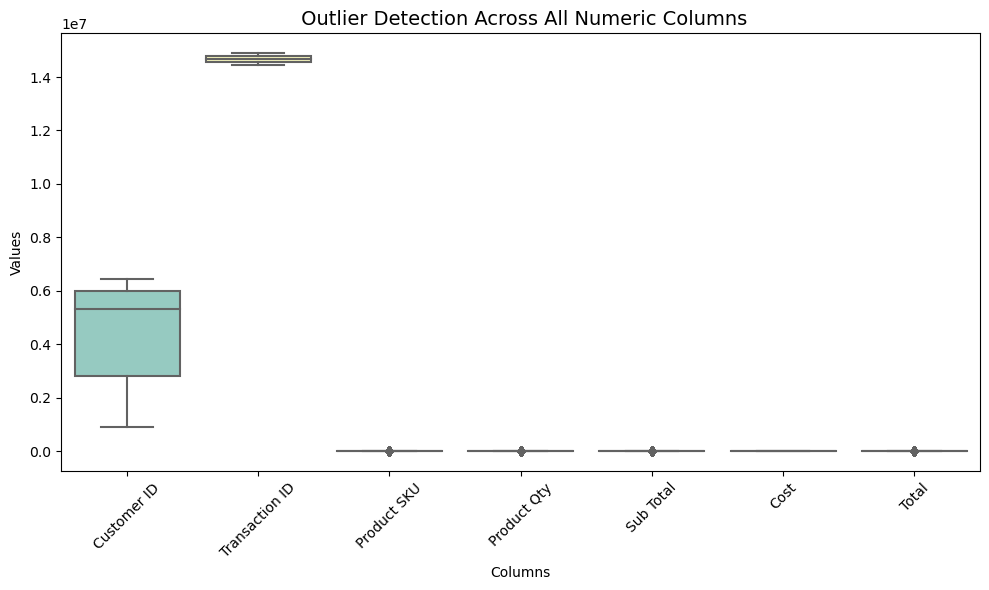

Customer ID: 0 outliers detected
Transaction ID: 0 outliers detected
Product SKU: 5192 outliers detected
Product Qty: 5183 outliers detected
Sub Total: 4032 outliers detected
Cost: 0 outliers detected
Total: 7024 outliers detected


In [53]:

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Summary to confirm which columns we are checking
print(" Numeric Columns:\n", numeric_cols.columns.tolist())

# Visualization - Multiple Boxplots
plt.figure(figsize=(10,6))
sns.boxplot(data=numeric_cols, palette='Set3')
plt.title(' Outlier Detection Across All Numeric Columns', fontsize=14)
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Detect outliers count using IQR method for each column
for col in numeric_cols.columns:
    Q1 = numeric_cols[col].quantile(0.25)
    Q3 = numeric_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = numeric_cols[(numeric_cols[col] < (Q1 - 1.5 * IQR)) | (numeric_cols[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers detected")


#### How many total transactions occurred?

Total Transactions: 6810


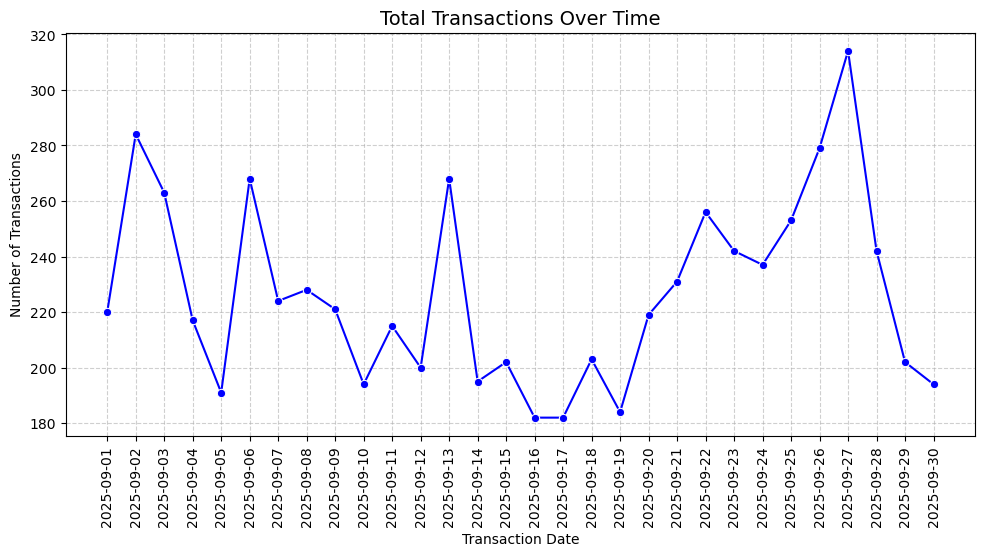

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Total number of transactions
total_transactions = df['Transaction ID'].nunique()
print("Total Transactions:", total_transactions)

# Visualization - Count of transactions per day
transactions_per_day = df.groupby('Transaction Date')['Transaction ID'].nunique().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=transactions_per_day, x='Transaction Date', y='Transaction ID', marker='o', color='blue')
plt.title('Total Transactions Over Time', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()



#### Which payment method was used most frequently?

myfatoorah                   28077
myfatoorah link               4419
cash                          2334
pos                           1484
myfatoorah,loyalty points       57
wallet,myfatoorah link          10
myfatoorah_apple_pay             7
myfatoorah,wallet                4
Name: Payment Method, dtype: int64


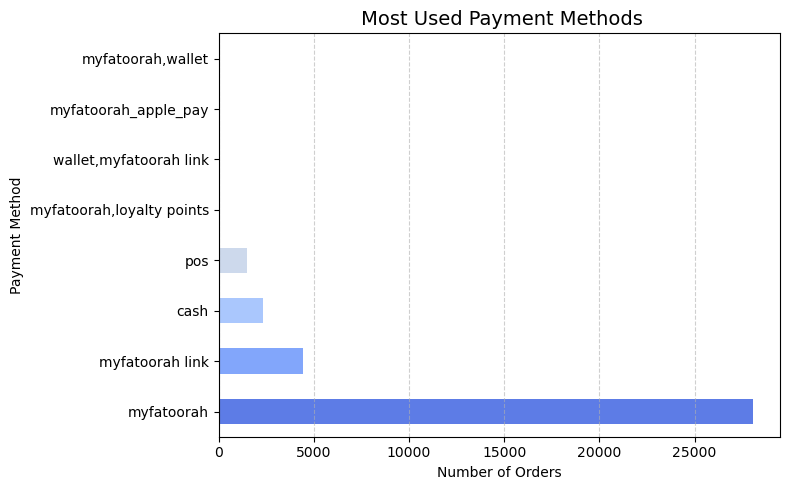

In [55]:

# 2 Count of payment methods
payment_counts = df['Payment Method'].value_counts()
print(payment_counts)

# Visualization - Horizontal Bar Chart (Pandas + Seaborn style)
plt.figure(figsize=(8,5))
payment_counts.plot(kind='barh', color=sns.color_palette('coolwarm', len(payment_counts)))
plt.title(' Most Used Payment Methods', fontsize=14)
plt.xlabel('Number of Orders')
plt.ylabel('Payment Method')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



#### What is the total revenue (sum of Total)?

 Total Revenue: 79124.15

Revenue by Payment Method:
 Payment Method
myfatoorah                   62493.5514
myfatoorah link               9325.0500
cash                          4930.4000
pos                           2214.9000
myfatoorah,loyalty points      110.8500
myfatoorah_apple_pay            24.7500
wallet,myfatoorah link          14.0000
myfatoorah,wallet               10.6500
Name: Total, dtype: float64


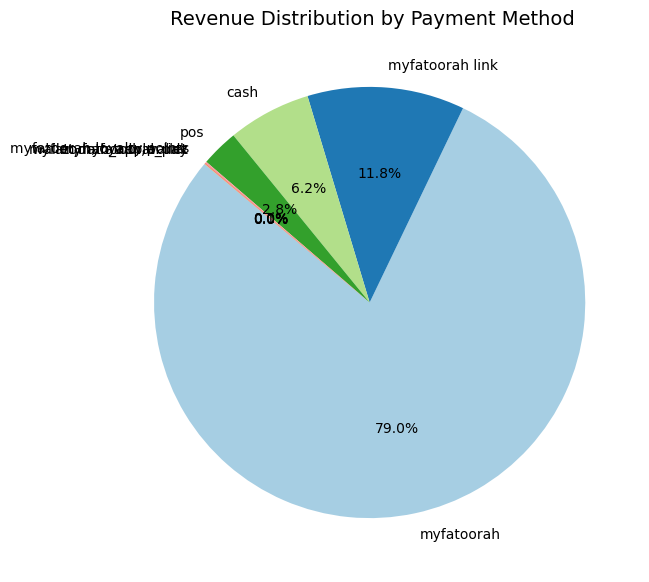

In [56]:


#  Total revenue overall
total_revenue = df['Total'].astype(float).sum()
print(" Total Revenue:", round(total_revenue, 2))

# Revenue by payment method
revenue_by_payment = df.groupby('Payment Method')['Total'].sum().sort_values(ascending=False)
print("\nRevenue by Payment Method:\n", revenue_by_payment)

# Visualization - Pie Chart
plt.figure(figsize=(10,7))
colors = plt.cm.Paired.colors
plt.pie(revenue_by_payment, labels=revenue_by_payment.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title(' Revenue Distribution by Payment Method', fontsize=14)
plt.show()


#####
Which province generated the highest total revenue?

Province
Hawalli              16801.8200
Mubarak Al-Kabeer    15968.6075
Kuwait City          15788.3350
Farwaniya            12393.6500
Ahmadi                9713.1000
Jahra                 5135.9000
-                     2348.7000
Riyadh                 226.2312
Doha                   157.6918
Eastern Province       132.4314
Makkah                  63.1959
Muharraq                57.6214
Al Rayyan               55.7404
Abu Dhabi               54.1792
Al Wakrah               53.5360
Ras Al Khaimah          47.5370
Sharjah                 39.0860
Al Ain                  30.6568
Fujairah                19.4724
Dubai                   19.1370
Al Daayen               17.5224
Name: Total, dtype: float64


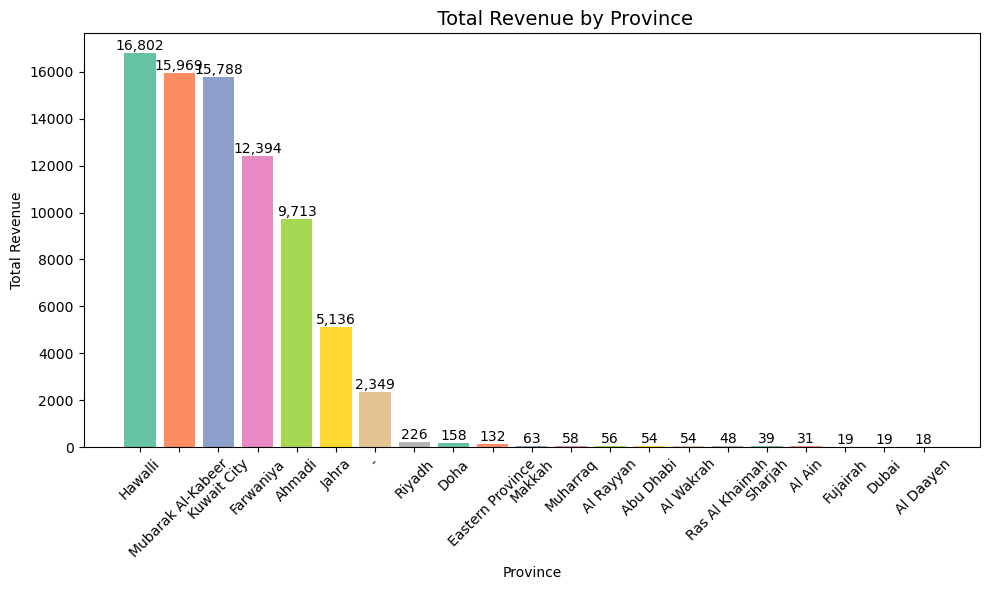

In [57]:
import matplotlib.pyplot as plt

#  Total revenue by province
revenue_by_province = df.groupby('Province')['Total'].sum().sort_values(ascending=False)
print(revenue_by_province)

# Visualization - Vertical Bar Chart
plt.figure(figsize=(10,6))
bars = plt.bar(revenue_by_province.index, revenue_by_province.values, color=plt.cm.Set2.colors)
plt.title('\
           Total Revenue by Province', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Total Revenue')

# Add value labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Which product types are most frequently sold?


Discounts                  64
composite                 957
stocked                  3751
Delivery Service Fee     6796
produced                24824
Name: Product Type, dtype: int64


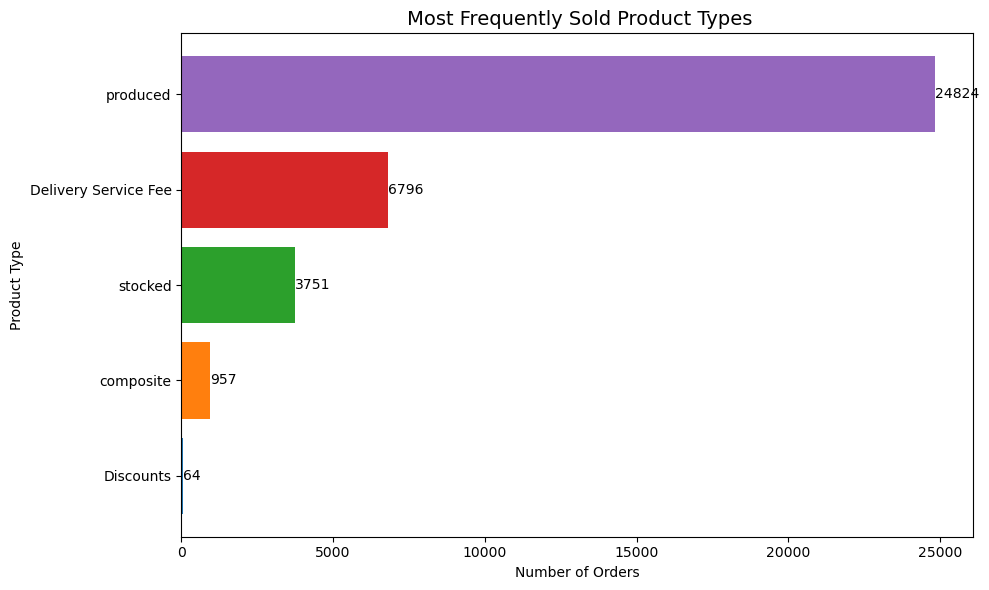

In [58]:
import matplotlib.pyplot as plt

#  Count number of sales per product type
product_sales = df['Product Type'].value_counts().sort_values(ascending=True)
print(product_sales)

# Visualization - Horizontal Bar Chart
plt.figure(figsize=(10,6))
bars = plt.barh(product_sales.index, product_sales.values, color=plt.cm.tab10.colors)
plt.title(' Most Frequently Sold Product Types', fontsize=14)
plt.xlabel('Number of Orders')
plt.ylabel('Product Type')

# Add value labels
for index, value in enumerate(product_sales.values):
    plt.text(value + 0.5, index, str(value), va='center')

plt.tight_layout()
plt.show()


#### Which drivers handled the highest number of deliveries?

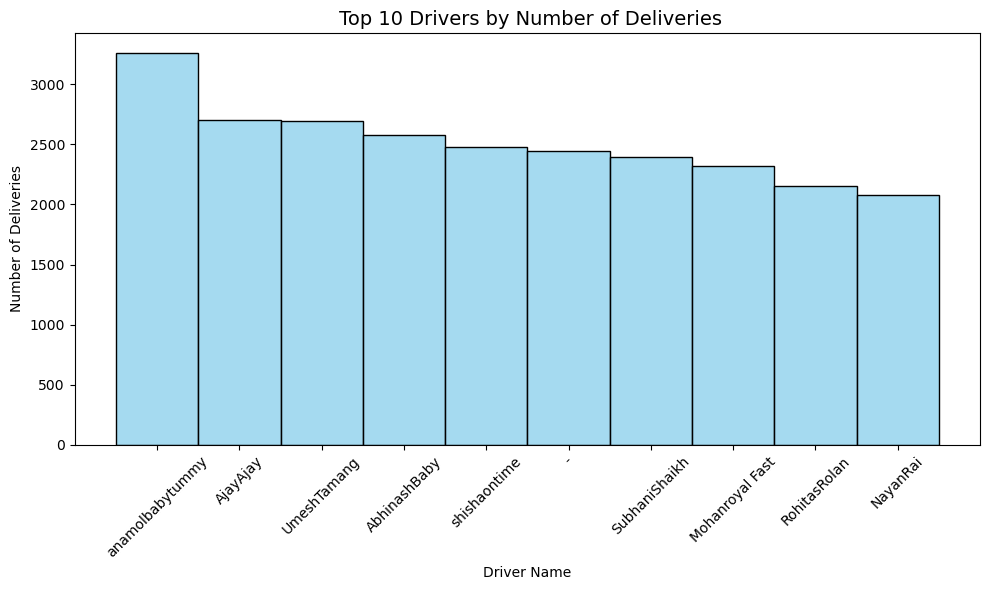

In [59]:



driver_deliveries = df['Driver Name'].value_counts().reset_index()
driver_deliveries.columns = ['Driver Name', 'Deliveries']

# Show top 10 drivers for clarity
top_drivers = driver_deliveries.head(10)

# Visualization - Seaborn histplot
plt.figure(figsize=(10,6))
sns.histplot(
    data=top_drivers,
    x='Driver Name',
    weights='Deliveries',
    bins=len(top_drivers),
    kde=False,
    color='skyblue'
)
plt.title(' Top 10 Drivers by Number of Deliveries', fontsize=14)
plt.xlabel('Driver Name')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


What is the relationship between key numerical features such as Sub Total, Cost, and Total?

 Correlation Matrix:
            Sub Total  Cost     Total
Sub Total   1.000000   NaN  0.949725
Cost             NaN   NaN       NaN
Total       0.949725   NaN  1.000000


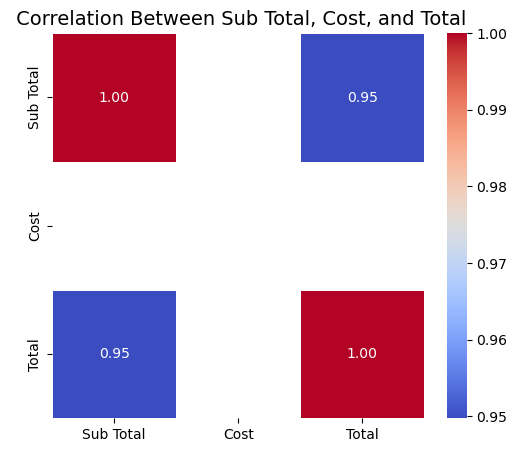

In [60]:
num_cols = ['Sub Total', 'Cost', 'Total']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Display correlation matrix
print(" Correlation Matrix:\n", corr_matrix)

# Visualization - Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title(' Correlation Between Sub Total, Cost, and Total', fontsize=14)
plt.show()

How does revenue vary by payment method?

              Payment Method       Total
0                       cash   4930.4000
1                 myfatoorah  62493.5514
2            myfatoorah link   9325.0500
3  myfatoorah,loyalty points    110.8500
4          myfatoorah,wallet     10.6500
5       myfatoorah_apple_pay     24.7500
6                        pos   2214.9000
7     wallet,myfatoorah link     14.0000


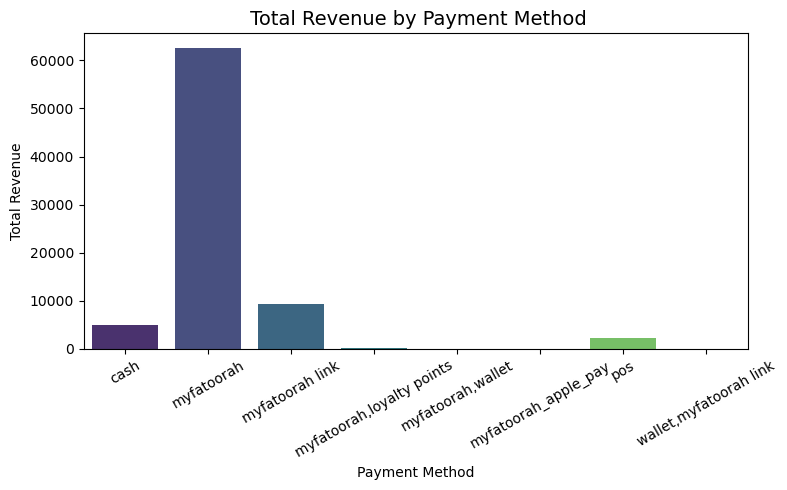

In [61]:



payment_revenue = df.groupby("Payment Method")["Total"].sum().reset_index()

print(payment_revenue)

# Visualization - Seaborn Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=payment_revenue, x="Payment Method", y="Total", palette="viridis")
plt.title(" Total Revenue by Payment Method", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


What is the distribution of Sub Total values?

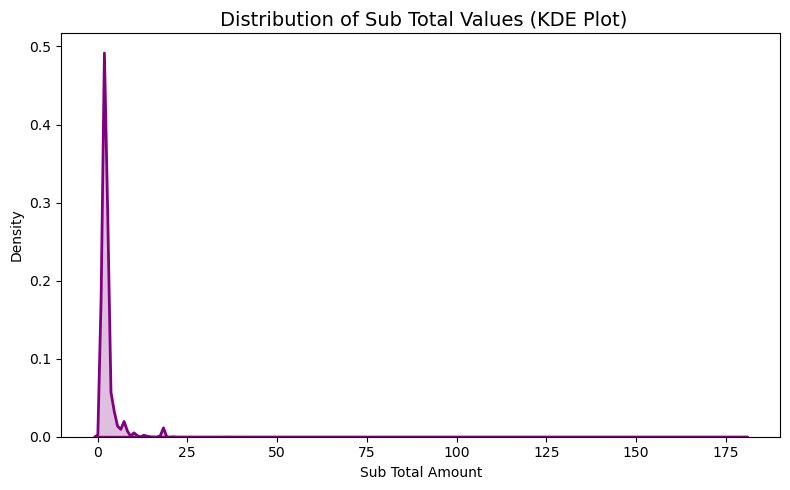

In [62]:



plt.figure(figsize=(8,5))
sns.kdeplot(df['Sub Total'], shade=True, color='purple', linewidth=2)
plt.title(' Distribution of Sub Total Values (KDE Plot)', fontsize=14)
plt.xlabel('Sub Total Amount')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


Which product categories generate the highest number of orders?

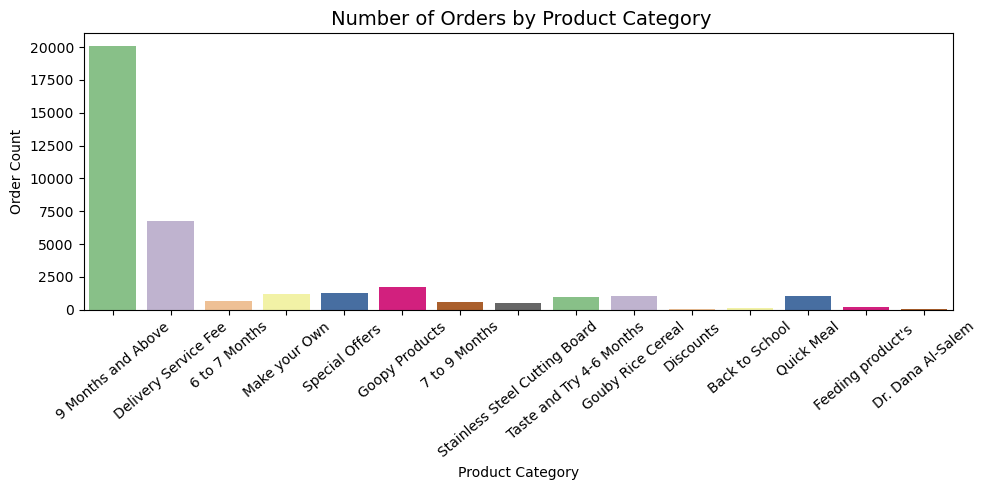

In [63]:



plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Category', palette='Accent')
plt.title(' Number of Orders by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Order Count')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()


How does the Total amount differ across different payment methods?

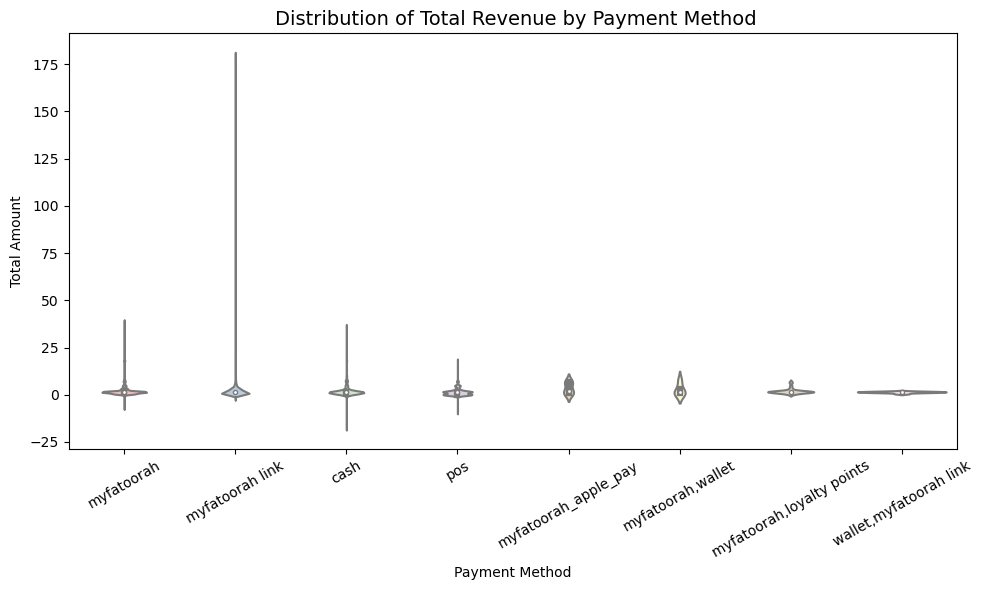

In [64]:



plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Payment Method', y='Total', palette='Pastel1')
plt.title(' Distribution of Total Revenue by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Total Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


What is the percentage share of each payment method?

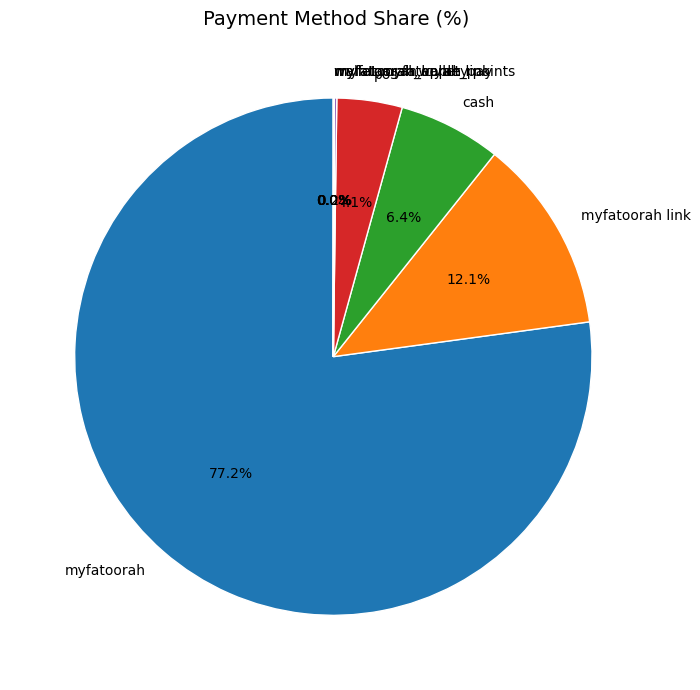

In [70]:



payment_counts = df['Payment Method'].value_counts()

plt.figure(figsize=(15,7))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title(' Payment Method Share (%)', fontsize=14)
plt.tight_layout()
plt.show()


What is the relationship between Sub Total and Total across all orders?

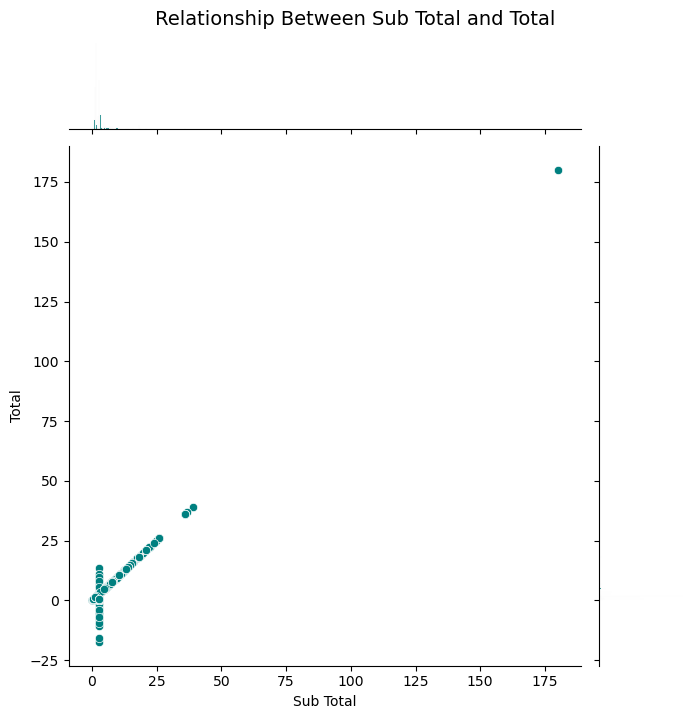

In [66]:


sns.jointplot(
    data=df,
    x='Sub Total',
    y='Total',
    kind='scatter',
    height=7,
    color='teal'
)

plt.suptitle(' Relationship Between Sub Total and Total', fontsize=14, y=1.02)
plt.show()


# 1. Suggest improvements based on the dataset

Q: What suggestions can you give the business after analyzing the dataset?
A:
Based on the data analysis, the following improvements can be suggested:

Improve data quality:

Remove duplicates

Handle missing values

Standardize formats (date, product names)

Perform feature engineering:

Create “Profit Margin” feature

Create “Customer Lifetime Value”

Create “Sales Category” (High, Medium, Low)

Optimize product strategy:

Identify high-selling vs low-selling products

Focus promotions on high-margin products

Remove or rebrand low-performance items

Improve pricing strategy:

Analyze price elasticity

Use historical trends to set competitive prices

Enhance customer segmentation:

Segment customers by spending

Create personalized marketing campaigns

✅ 2. Recommendations from a Sales Dataset

Q: What recommendations would you give to increase sales?
A:

Promote top-selling products through ads and bundle offers.

Increase discount frequency during low sales months.

Improve stock availability of frequently sold items.

Optimize delivery time to improve customer satisfaction.

Use customer feedback to identify issues and fix them.

✅ 3. Recommendation for Outlier Handling

Q: What should we do if outliers are found in the dataset?
A:

Verify if outliers are errors. If yes → remove them.

If outliers are genuine business values:

Use transformation (log, sqrt)

Use robust scaling

Treat them with cap/floor (winsorization)

Model-based handling:

Use tree-based models (less sensitive to outliers)

✅ 4. Recommendation for Feature Engineering

Q: What features can we create to improve model performance?
A:

Date-based features:

Day, Month, Quarter, Year

Weekend or Weekday

Customer features:

Total_purchase

Avg_purchase_value

Loyalty_score

Product features:

Profit_margin

Sales_category

Text features:

Word count

Sentiment score

✅ 5. Recommendations for Visualizations

Q: What visualizations should be added for better insights?
A:

Heatmap → correlation

Histogram → distribution

Boxplot → outliers

Line chart → sales trend

Bar chart → category comparison

Scatter plot → relationship between price & sales